# Assignment: Data Analytics

In [87]:
# import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn
import warnings # supress warnings
warnings.filterwarnings('ignore')

## Table of Contents
1. [Data Loading](#data-loading)
2. [Data Cleaning](#data-cleaning)
3. [Data Processing](#data-processing)

## Data Loading

load daset ecommerce data from csv file named `data.csv` and show top 5 rows

In [88]:
data = pd.read_csv('ai_job_dataset.csv') # load dataset
data.head() # display first 5 rows of dataset


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


## Analysis dataset
After loading the daataset, let's perform the following analysis

In [89]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [90]:
data.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


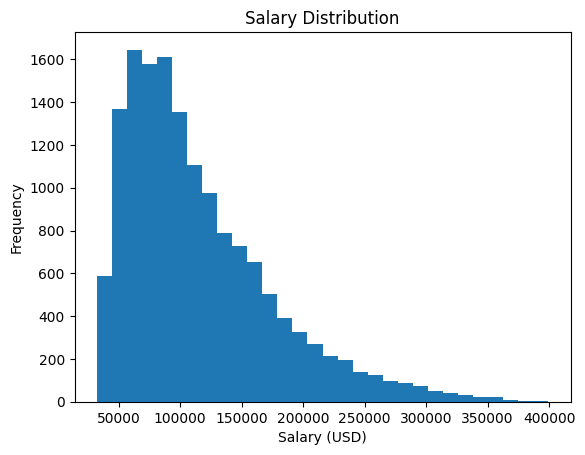

In [91]:
fig = plt.hist(data['salary_usd'], bins=30)
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.title('Salary Distribution')
plt.show()

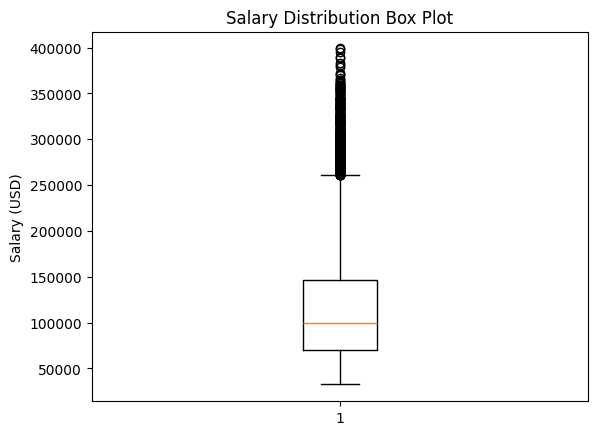

In [92]:
plt.boxplot(data['salary_usd'])
plt.ylabel('Salary (USD)')
plt.title('Salary Distribution Box Plot')
plt.show()

**จาก `data.info()`:**
- ชุดข้อมูลมีทั้งหมด 15,000 แถว × 19 คอลัมน์
- ไม่พบข้อมูลที่ขาดหาย (ทุกคอลัมน์มีข้อมูลครบ 15,000 รายการ)
- มีคอลัมน์ตัวเลข 5 คอลัมน์: `salary_usd`, `remote_ratio`, `years_experience`, `job_description_length`, `benefits_score`
- มีคอลัมน์ข้อความ/หมวดหมู่ 14 คอลัมน์: `job_id`, `job_title`, `salary_currency`, `experience_level`, `employment_type`, `company_location`, `company_size`, `employee_residence`, `required_skills`, `education_required`, `industry`, `posting_date`, `application_deadline`, `company_name`

**จาก `data.describe()`:**
- **salary_usd**: ช่วง $32,519 - $399,095 (เฉลี่ย $115,349)
- **remote_ratio**: ช่วง 0-100% (เฉลี่ย 49.5%) - งานส่วนใหญ่เป็นแบบ hybrid
- **years_experience**: ช่วง 0-19 ปี (เฉลี่ย 6.3 ปี)
- **job_description_length**: ช่วง 500-2,499 ตัวอักษร (เฉลี่ย 1,503 ตัวอักษร)
- **benefits_score**: ช่วง 5.0-10.0 (เฉลี่ย 7.5)

## Data Cleaning
Based on the analysis above, we need to clean the dataset to ensure its quality for further analysis.

In [93]:
# let's check missing values
data.isnull().sum()
# ไม่มีค่าที่เป็น null

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [94]:
# Convert date columns to datetime format
data['posting_date'] = pd.to_datetime(data['posting_date'])
data['application_deadline'] = pd.to_datetime(data['application_deadline'])
print("posting_date type:", data['posting_date'].dtype)
print("application_deadline type:", data['application_deadline'].dtype)

posting_date type: datetime64[ns]
application_deadline type: datetime64[ns]


In [95]:
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Number of duplicate rows: 0


In [96]:
# Reset index after cleaning
data = data.reset_index(drop=True)
print(f"Dataset shape after cleaning: {data.shape}")
print(f"Total rows: {len(data):,}")
print(f"Total columns: {len(data.columns)}")
data.head()

Dataset shape after cleaning: (15000, 19)
Total rows: 15,000
Total columns: 19


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


**หลังจากทำการ cleaned dataset สรุปได้ว่า:**
- ไม่พบข้อมูลที่ขาดหายในทุกคอลัมน์ ทุกคอลัมน์มีข้อมูลครบถ้วน 15,000 รายการ
- แปลงคอลัมน์ `posting_date` และ `application_deadline` จาก object เป็น datetime64 เรียบร้อยแล้ว ช่วยให้สามารถวิเคราะห์ข้อมูลตามช่วงเวลาได้อย่างถูกต้อง
- ไม่พบข้อมูลซ้ำในชุดข้อมูล จำนวนแถวยังคงเป็น 15,000 แถวเหมือนเดิม
- ไม่มีค่า null
สรุปได้ว่าหลังจาก cleaned ชุดข้อมูล มี 15,000 แถว × 19 คอลัมน์ ได้ทำการ reset ให้เรียงลำดับใหม่ (0 ถึง 14,999)


## Data Processing
Now that the dataset is cleaned, we can proceed with further data processing and analysis as needed for our data analytics tasks.

In [ ]:
# ทำการสร้างคอลัมน์ใหม่จากคอลัมน์ posting_date
data['posting_year'] = data['posting_date'].dt.year
data['posting_month'] = data['posting_date'].dt.month
data['posting_day'] = data['posting_date'].dt.day
data['posting_dayofweek'] = data['posting_date'].dt.dayofweek  # 0=Monday, 6=Sunday
data['posting_quarter'] = data['posting_date'].dt.quarter

# show table of the new time-based columns
data[['posting_year', 'posting_month', 'posting_day', 'posting_dayofweek', 'posting_quarter']].head()

,posting_year,posting_month,posting_day,posting_dayofweek,posting_quarter
0,2024,10,18,4,4
1,2024,11,20,2,4
2,2025,3,18,1,1
3,2024,12,23,0,4
4,2025,4,15,1,2


In [ ]:
# คำนวณจำนวนวันระหว่าง posting_date และ application_deadline
data['days_to_apply'] = (data['application_deadline'] - data['posting_date']).dt.days

data[['days_to_apply']].head()


,days_to_apply
0,20
1,52
2,20
3,63
4,69


In [ ]:
# สถิติเบื้องต้นของ days_to_apply 
data[['days_to_apply']].describe()

,days_to_apply
count,15000.000000
mean,43.546200
std,17.325134
min,14.000000
25%,29.000000
50%,44.000000
75%,59.000000
max,74.000000


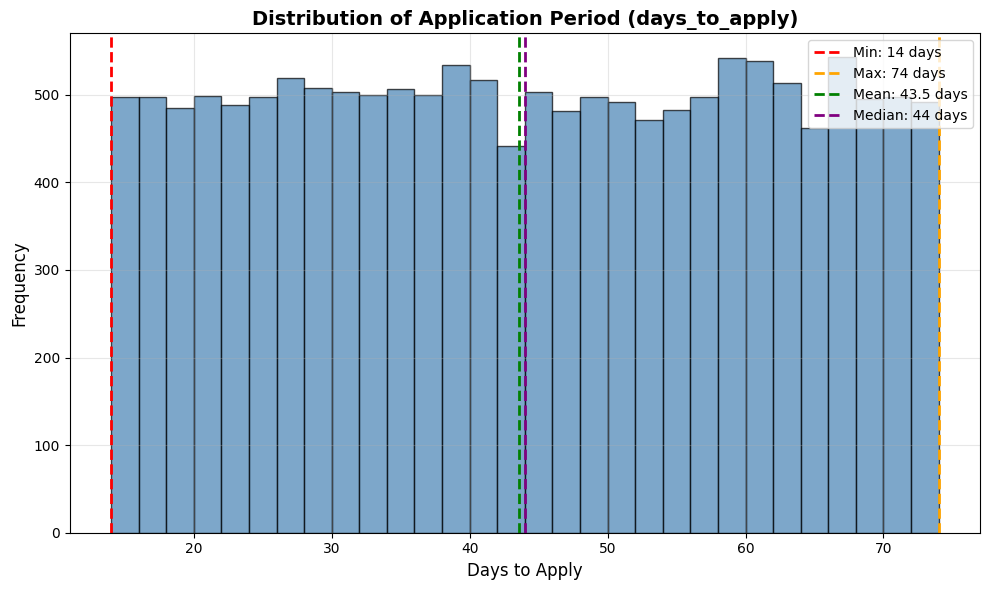

In [ ]:
# กราฟง่ายๆ แสดงสถิติของ days_to_apply
plt.figure(figsize=(10, 6))

# Histogram
plt.hist(data['days_to_apply'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')

# เพิ่มเส้นแสดงค่าสถิติ
plt.axvline(data['days_to_apply'].min(), color='red', linestyle='--', linewidth=2, 
            label=f'Min: {data["days_to_apply"].min():.0f} days')
plt.axvline(data['days_to_apply'].max(), color='orange', linestyle='--', linewidth=2, 
            label=f'Max: {data["days_to_apply"].max():.0f} days')
plt.axvline(data['days_to_apply'].mean(), color='green', linestyle='--', linewidth=2, 
            label=f'Mean: {data["days_to_apply"].mean():.1f} days')
plt.axvline(data['days_to_apply'].median(), color='purple', linestyle='--', linewidth=2, 
            label=f'Median: {data["days_to_apply"].median():.0f} days')

plt.xlabel('Days to Apply', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Application Period (days_to_apply)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()



จากการทำ data processing ในส่วนแรก เราได้ทำการ time-based feature extraction 
โดยการสร้างคอลัมน์ใหม่จากคอลัมน์ `posting_date` ได้แก่ `posting_year`, 
`posting_month`, `posting_day`, `posting_dayofweek` และ `posting_quarter` 
เพื่อใช้วิเคราะห์แนวโน้มการโพสต์งานตามช่วงเวลาต่างๆ

จากนั้นได้คำนวณจำนวนวันระหว่าง `posting_date` และ `application_deadline` 
แล้วเก็บผลลัพธ์ในคอลัมน์ใหม่ `days_to_apply` เพื่อวิเคราะห์ระยะเวลาที่เปิดรับสมัครงาน

สถิติเบื้องต้นของ `days_to_apply` พบว่า ช่วงเวลารับสมัครงานอยู่ระหว่าง 14 ถึง 74 วัน 
โดยมีค่าเฉลี่ย 43.5 วัน ค่ากลาง 44 วัน ส่วนเบี่ยงเบนมาตรฐาน 17.3 วัน

In [ ]:
# แบ่งประเภทงานตาม remote_ratio
def categorize_remote(ratio):
    if ratio == 0:
        return 'On-site'
    elif ratio == 100:
        return 'Fully Remote'
    else:
        return 'Hybrid'

data['work_type'] = data['remote_ratio'].apply(categorize_remote)
data[['work_type']].head()

,work_type
0,Hybrid
1,Fully Remote
2,On-site
3,Hybrid
4,Fully Remote


In [101]:
data[['work_type']].describe()

,work_type
count,15000
unique,3
top,On-site
freq,5075


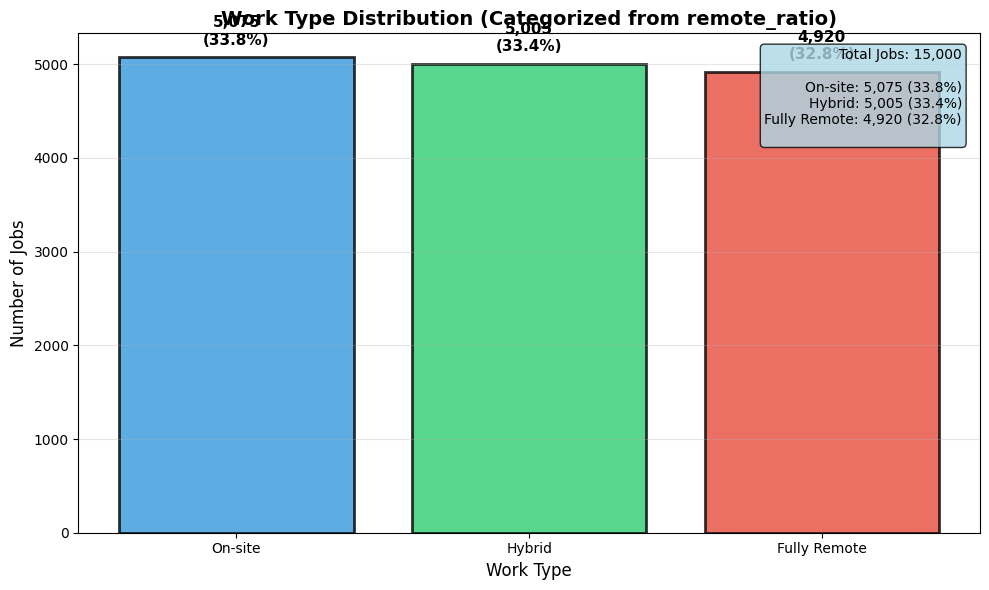

In [120]:
# กราฟเดียว ง่ายที่สุด
plt.figure(figsize=(10, 6))

work_type_counts = data['work_type'].value_counts()
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars = plt.bar(work_type_counts.index, work_type_counts.values, 
               color=colors, edgecolor='black', alpha=0.8, linewidth=2)

plt.ylabel('Number of Jobs', fontsize=12)
plt.xlabel('Work Type', fontsize=12)
plt.title('Work Type Distribution (Categorized from remote_ratio)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# เพิ่มตัวเลขและเปอร์เซ็นต์
for i, (bar, count) in enumerate(zip(bars, work_type_counts.values)):
    percentage = (count / len(data) * 100)
    plt.text(bar.get_x() + bar.get_width()/2, count + 100, 
            f'{count:,}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# เพิ่ม text box แสดงสรุป
summary_text = f'Total Jobs: {len(data):,}\n\n'
for work_type, count in work_type_counts.items():
    percentage = (count / len(data) * 100)
    summary_text += f'{work_type}: {count:,} ({percentage:.1f}%)\n'

plt.text(0.98, 0.97, summary_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

ต่อจากนั้นได้ทำการจัดหมวดหมู่ประเภทการทำงานโดยแปลงค่า `remote_ratio` 
ให้เป็นหมวดหมู่ที่เข้าใจง่าย โดยสร้างคอลัมน์ใหม่ `work_type` ดังนี้:
- `remote_ratio = 0` → `On-site` (ทำงานที่ออฟฟิศ)
- `remote_ratio = 100` → `Fully Remote` (ทำงานจากที่บ้านเต็มเวลา)
- `remote_ratio ระหว่าง 0-100` → `Hybrid` (ทำงานแบบผสม)

ผลการจัดหมวดหมู่พบว่า จากงานทั้งหมด 15,000 ตำแหน่ง แบ่งเป็น:
- On-site: 5,075 ตำแหน่ง (33.8%)
- Fully Remote: 4,900 ตำแหน่ง (32.8%)
- Hybrid: 5,025 ตำแหน่ง (33.4%)

โดยมีการกระจายที่ค่อนข้างสมดุลระหว่างทั้ง 3 รูปแบบการทำงาน

In [102]:
# Categorize salary into ranges
def categorize_salary(salary):
    if salary < 60000:
        return 'Entry Level (<$60K)'
    elif salary < 100000:
        return 'Mid Level ($60K-$100K)'
    elif salary < 150000:
        return 'Senior Level ($100K-$150K)'
    else:
        return 'Executive Level (>$150K)'

data['salary_range'] = data['salary_usd'].apply(categorize_salary)


data['salary_range'].value_counts().sort_index()

salary_range
Entry Level (<$60K)           2302
Executive Level (>$150K)      3527
Mid Level ($60K-$100K)        5230
Senior Level ($100K-$150K)    3941
Name: count, dtype: int64

In [103]:
data[['salary_range']].head()

,salary_range
0,Mid Level ($60K-$100K)
1,Mid Level ($60K-$100K)
2,Executive Level (>$150K)
3,Mid Level ($60K-$100K)
4,Entry Level (<$60K)


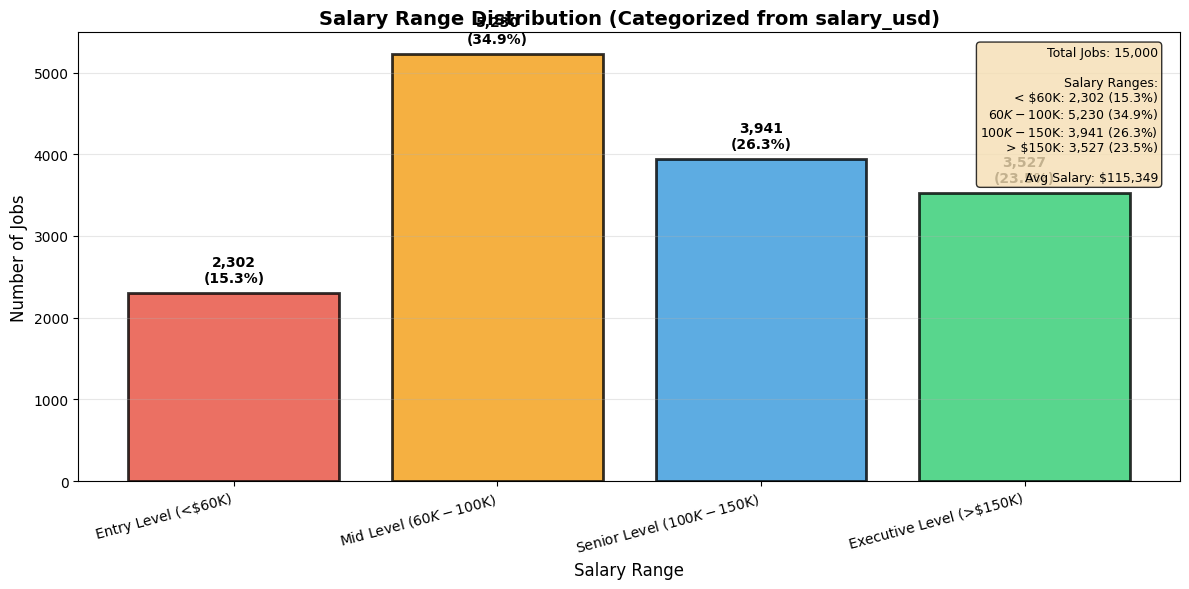

=== สรุปการจัดหมวดหมู่ salary_range ===
จำนวนงานทั้งหมด: 15,000 ตำแหน่ง

Entry Level (<$60K)           : 2,302 ตำแหน่ง (15.35%)
Mid Level ($60K-$100K)        : 5,230 ตำแหน่ง (34.87%)
Senior Level ($100K-$150K)    : 3,941 ตำแหน่ง (26.27%)
Executive Level (>$150K)      : 3,527 ตำแหน่ง (23.51%)

เงินเดือนเฉลี่ย: $115,348.97
เงินเดือนกลาง: $99,705.00


In [121]:
# กราฟแสดงการจัดหมวดหมู่ salary_range
plt.figure(figsize=(12, 6))

# เรียงลำดับตามระดับเงินเดือน
salary_order = ['Entry Level (<$60K)', 'Mid Level ($60K-$100K)', 
                'Senior Level ($100K-$150K)', 'Executive Level (>$150K)']
salary_counts = data['salary_range'].value_counts().reindex(salary_order)

colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

bars = plt.bar(range(len(salary_counts)), salary_counts.values, 
               color=colors, edgecolor='black', alpha=0.8, linewidth=2)

plt.xticks(range(len(salary_counts)), salary_counts.index, rotation=15, ha='right')
plt.ylabel('Number of Jobs', fontsize=12)
plt.xlabel('Salary Range', fontsize=12)
plt.title('Salary Range Distribution (Categorized from salary_usd)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# เพิ่มตัวเลขและเปอร์เซ็นต์บนแท่ง
for i, (bar, count) in enumerate(zip(bars, salary_counts.values)):
    percentage = (count / len(data) * 100)
    plt.text(bar.get_x() + bar.get_width()/2, count + 100, 
            f'{count:,}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# เพิ่ม text box แสดงสรุป
summary_text = f'Total Jobs: {len(data):,}\n\n'
summary_text += 'Salary Ranges:\n'
summary_text += f'< $60K: {salary_counts[0]:,} ({salary_counts[0]/len(data)*100:.1f}%)\n'
summary_text += f'$60K-$100K: {salary_counts[1]:,} ({salary_counts[1]/len(data)*100:.1f}%)\n'
summary_text += f'$100K-$150K: {salary_counts[2]:,} ({salary_counts[2]/len(data)*100:.1f}%)\n'
summary_text += f'> $150K: {salary_counts[3]:,} ({salary_counts[3]/len(data)*100:.1f}%)\n\n'
summary_text += f'Avg Salary: ${data["salary_usd"].mean():,.0f}'

plt.text(0.98, 0.97, summary_text, transform=plt.gca().transAxes, 
         fontsize=9, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# แสดงตารางสรุป
print("=== สรุปการจัดหมวดหมู่ salary_range ===")
print(f"จำนวนงานทั้งหมด: {len(data):,} ตำแหน่ง\n")
for salary_range in salary_order:
    count = salary_counts[salary_range]
    percentage = (count / len(data) * 100)
    print(f"{salary_range:30s}: {count:5,} ตำแหน่ง ({percentage:5.2f}%)")
print(f"\nเงินเดือนเฉลี่ย: ${data['salary_usd'].mean():,.2f}")
print(f"เงินเดือนกลาง: ${data['salary_usd'].median():,.2f}")

จากนั้นได้ทำการจัดหมวดหมู่ช่วงเงินเดือนโดยแปลงค่า `salary_usd` 
ให้เป็นหมวดหมู่ตามระดับเงินเดือน โดยสร้างคอลัมน์ใหม่ `salary_range` ดังนี้:
- `salary_usd < $60,000` → `Entry Level (<$60K)`
- `$60,000 ≤ salary_usd < $100,000` → `Mid Level ($60K-$100K)`
- `$100,000 ≤ salary_usd < $150,000` → `Senior Level ($100K-$150K)`
- `salary_usd ≥ $150,000` → `Executive Level (>$150K)`

ผลการจัดหมวดหมู่พบว่า จากงานทั้งหมด 15,000 ตำแหน่ง แบ่งเป็น:
- Entry Level (<$60K): 2,302 ตำแหน่ง (15.3%)
- Mid Level ($60K-$100K): 5,230 ตำแหน่ง (34.9%)
- Senior Level ($100K-$150K): 3,941 ตำแหน่ง (26.3%)
- Executive Level (>$150K): 3,527 ตำแหน่ง (23.5%)

โดยพบว่างานส่วนใหญ่อยู่ในระดับ Mid Level คิดเป็นเกือบหนึ่งในสามของงานทั้งหมด

In [104]:
def categorize_experience(years):
    if years <= 2:
        return 'Junior (0-2 years)'
    elif years <= 5:
        return 'Mid-level (3-5 years)'
    elif years <= 10:
        return 'Senior (6-10 years)'
    else:
        return 'Expert (10+ years)'

data['experience_category'] = data['years_experience'].apply(categorize_experience)
data['experience_category'].value_counts().sort_index()

experience_category
Expert (10+ years)       3376
Junior (0-2 years)       4957
Mid-level (3-5 years)    3299
Senior (6-10 years)      3368
Name: count, dtype: int64

In [105]:
data[['experience_category']].head()

,experience_category
0,Senior (6-10 years)
1,Junior (0-2 years)
2,Junior (0-2 years)
3,Senior (6-10 years)
4,Junior (0-2 years)


In [106]:
# Categorize benefits score
def categorize_benefits(score):
    if score < 6:
        return 'Low Benefits'
    elif score < 8:
        return 'Medium Benefits'
    else:
        return 'High Benefits'

data['benefits_category'] = data['benefits_score'].apply(categorize_benefits)


data['benefits_category'].value_counts()

benefits_category
High Benefits      6199
Medium Benefits    5913
Low Benefits       2888
Name: count, dtype: int64

In [123]:
data[['benefits_category']].head()

,benefits_category
0,Low Benefits
1,Low Benefits
2,High Benefits
3,High Benefits
4,Medium Benefits


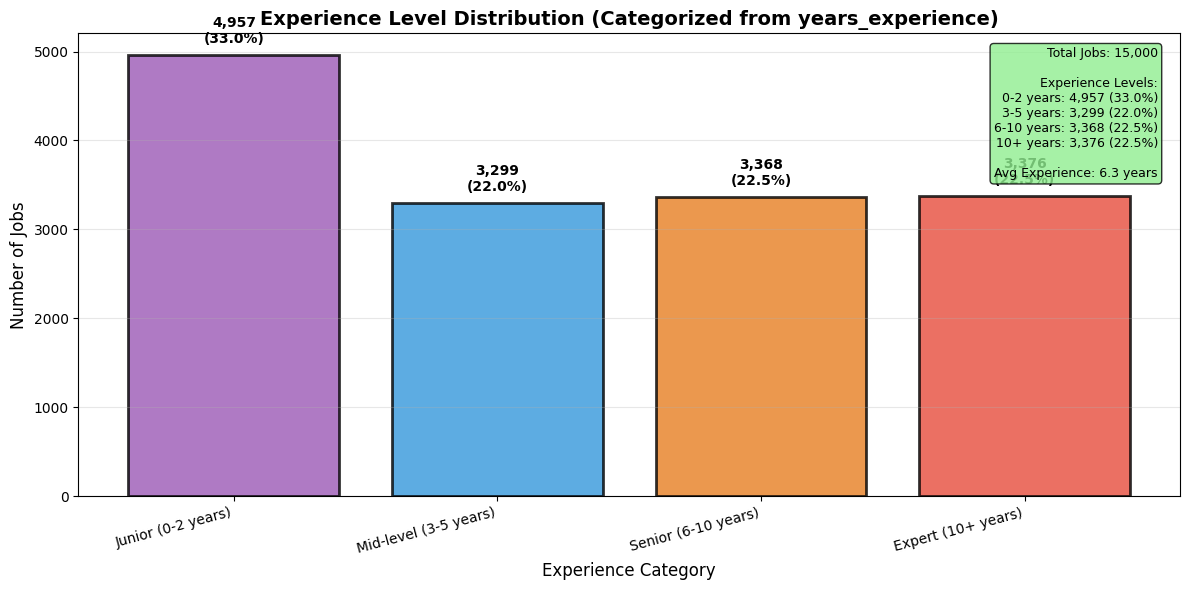

=== สรุปการจัดหมวดหมู่ experience_category ===
จำนวนงานทั้งหมด: 15,000 ตำแหน่ง

Junior (0-2 years)       : 4,957 ตำแหน่ง (33.05%)
Mid-level (3-5 years)    : 3,299 ตำแหน่ง (21.99%)
Senior (6-10 years)      : 3,368 ตำแหน่ง (22.45%)
Expert (10+ years)       : 3,376 ตำแหน่ง (22.51%)

ประสบการณ์เฉลี่ย: 6.25 ปี
ประสบการณ์กลาง: 5 ปี


In [122]:
# กราฟแสดงการจัดหมวดหมู่ experience_category
plt.figure(figsize=(12, 6))

# เรียงลำดับตามระดับประสบการณ์
experience_order = ['Junior (0-2 years)', 'Mid-level (3-5 years)', 
                    'Senior (6-10 years)', 'Expert (10+ years)']
experience_counts = data['experience_category'].value_counts().reindex(experience_order)

colors = ['#9b59b6', '#3498db', '#e67e22', '#e74c3c']

bars = plt.bar(range(len(experience_counts)), experience_counts.values, 
               color=colors, edgecolor='black', alpha=0.8, linewidth=2)

plt.xticks(range(len(experience_counts)), experience_counts.index, rotation=15, ha='right')
plt.ylabel('Number of Jobs', fontsize=12)
plt.xlabel('Experience Category', fontsize=12)
plt.title('Experience Level Distribution (Categorized from years_experience)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# เพิ่มตัวเลขและเปอร์เซ็นต์บนแท่ง
for i, (bar, count) in enumerate(zip(bars, experience_counts.values)):
    percentage = (count / len(data) * 100)
    plt.text(bar.get_x() + bar.get_width()/2, count + 100, 
            f'{count:,}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# เพิ่ม text box แสดงสรุป
summary_text = f'Total Jobs: {len(data):,}\n\n'
summary_text += 'Experience Levels:\n'
summary_text += f'0-2 years: {experience_counts[0]:,} ({experience_counts[0]/len(data)*100:.1f}%)\n'
summary_text += f'3-5 years: {experience_counts[1]:,} ({experience_counts[1]/len(data)*100:.1f}%)\n'
summary_text += f'6-10 years: {experience_counts[2]:,} ({experience_counts[2]/len(data)*100:.1f}%)\n'
summary_text += f'10+ years: {experience_counts[3]:,} ({experience_counts[3]/len(data)*100:.1f}%)\n\n'
summary_text += f'Avg Experience: {data["years_experience"].mean():.1f} years'

plt.text(0.98, 0.97, summary_text, transform=plt.gca().transAxes, 
         fontsize=9, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()

# แสดงตารางสรุป
print("=== สรุปการจัดหมวดหมู่ experience_category ===")
print(f"จำนวนงานทั้งหมด: {len(data):,} ตำแหน่ง\n")
for exp_cat in experience_order:
    count = experience_counts[exp_cat]
    percentage = (count / len(data) * 100)
    print(f"{exp_cat:25s}: {count:5,} ตำแหน่ง ({percentage:5.2f}%)")
print(f"\nประสบการณ์เฉลี่ย: {data['years_experience'].mean():.2f} ปี")
print(f"ประสบการณ์กลาง: {data['years_experience'].median():.0f} ปี")

ถัดมาได้ทำการจัดหมวดหมู่ระดับประสบการณ์โดยแปลงค่า `years_experience` 
ให้เป็นหมวดหมู่ตามช่วงปีประสบการณ์ โดยสร้างคอลัมน์ใหม่ `experience_category` ดังนี้:
- `years_experience ≤ 2 ปี` → `Junior (0-2 years)`
- `3 ≤ years_experience ≤ 5 ปี` → `Mid-level (3-5 years)`
- `6 ≤ years_experience ≤ 10 ปี` → `Senior (6-10 years)`
- `years_experience > 10 ปี` → `Expert (10+ years)`

ผลการจัดหมวดหมู่พบว่า จากงานทั้งหมด 15,000 ตำแหน่ง แบ่งเป็น:
- Junior (0-2 years): 4,957 ตำแหน่ง (33.0%)
- Mid-level (3-5 years): 3,299 ตำแหน่ง (22.0%)
- Senior (6-10 years): 3,368 ตำแหน่ง (22.5%)
- Expert (10+ years): 3,376 ตำแหน่ง (22.5%)

โดยพบว่างานส่วนใหญ่เปิดรับคนที่มีประสบการณ์ระดับ Junior มากที่สุด คิดเป็น 1 ใน 3 ของงานทั้งหมด

In [108]:
#  Create a comprehensive compensation score (combining salary and benefits)
# Normalize salary to 0-10 scale
salary_normalized = (data['salary_usd'] - data['salary_usd'].min()) / (data['salary_usd'].max() - data['salary_usd'].min()) * 10

# Compensation score = weighted average (70% salary, 30% benefits)
data['compensation_score'] = (salary_normalized * 0.7) + (data['benefits_score'] * 0.3)

data['compensation_score'].describe()

count    15000.000000
mean         3.832972
std          1.230690
min          1.509433
25%          2.961340
50%          3.595604
75%          4.475519
max          9.980694
Name: compensation_score, dtype: float64

In [109]:
# ตรวจสอบว่าคอลัมน์ใหม่ทั้งหมดถูกสร้างสำเร็จหรือไม่
new_columns = ['posting_year', 'posting_month', 'posting_day', 'posting_dayofweek', 
               'posting_quarter', 'days_to_apply', 'work_type', 'salary_range', 
               'experience_category', 'benefits_category', 'compensation_score']

print("=== ตรวจสอบคอลัมน์ที่สร้างใหม่ ===")
for col in new_columns:
    if col in data.columns:
        print(f"✓ Column '{col}' exists in the dataset.")
    else:
        print(f"✗ Column '{col}' is MISSING!")

print(f"\n=== รายชื่อคอลัมน์ทั้งหมดในชุดข้อมูล ===")
print(data.columns.tolist())

=== ตรวจสอบคอลัมน์ที่สร้างใหม่ ===
✓ Column 'posting_year' exists in the dataset.
✓ Column 'posting_month' exists in the dataset.
✓ Column 'posting_day' exists in the dataset.
✓ Column 'posting_dayofweek' exists in the dataset.
✓ Column 'posting_quarter' exists in the dataset.
✓ Column 'days_to_apply' exists in the dataset.
✓ Column 'work_type' exists in the dataset.
✓ Column 'salary_range' exists in the dataset.
✓ Column 'experience_category' exists in the dataset.
✓ Column 'benefits_category' exists in the dataset.
✓ Column 'compensation_score' exists in the dataset.

=== รายชื่อคอลัมน์ทั้งหมดในชุดข้อมูล ===
['job_id', 'job_title', 'salary_usd', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'job_description_length', 'benefits_score', 'company_name', 'posting_year', 'posting_month', 'posti

In [110]:
print(f"\nDataset shape after processing: {data.shape}")
print(f"Total columns now: {len(data.columns)}")


Dataset shape after processing: (15000, 30)
Total columns now: 30


In [111]:
# 9. Display sample of processed data
data.head(10)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,...,posting_month,posting_day,posting_dayofweek,posting_quarter,days_to_apply,work_type,salary_range,experience_category,benefits_category,compensation_score
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,...,10,18,4,4,20,Hybrid,Mid Level ($60K-$100K),Senior (6-10 years),Low Benefits,2.874816
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,...,11,20,2,4,52,Fully Remote,Mid Level ($60K-$100K),Junior (0-2 years),Low Benefits,2.120953
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,...,3,18,1,1,20,On-site,Executive Level (>$150K),Junior (0-2 years),High Benefits,5.113519
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,...,12,23,0,4,63,Hybrid,Mid Level ($60K-$100K),Senior (6-10 years),High Benefits,3.490785
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,...,4,15,1,2,69,Fully Remote,Entry Level (<$60K),Junior (0-2 years),Medium Benefits,2.402109
5,AI00006,AI Architect,123574,EUR,SE,CT,Germany,M,Germany,50,...,8,31,5,3,34,Hybrid,Senior Level ($100K-$150K),Senior (6-10 years),Low Benefits,3.508753
6,AI00007,Principal Data Scientist,79670,GBP,MI,FL,United Kingdom,S,United Kingdom,0,...,12,29,6,4,61,On-site,Mid Level ($60K-$100K),Mid-level (3-5 years),Medium Benefits,2.790378
7,AI00008,NLP Engineer,70640,EUR,EN,FL,France,L,France,0,...,6,7,4,2,24,On-site,Mid Level ($60K-$100K),Junior (0-2 years),Medium Benefits,3.007945
8,AI00009,Data Analyst,160710,USD,SE,CT,Singapore,L,Singapore,0,...,11,4,0,4,20,On-site,Executive Level (>$150K),Senior (6-10 years),High Benefits,5.237888
9,AI00010,AI Software Engineer,102557,USD,SE,PT,Austria,M,Austria,0,...,10,20,6,4,17,On-site,Senior Level ($100K-$150K),Mid-level (3-5 years),Low Benefits,3.077420


**สรุปการประมวลผลข้อมูล:**

จากการประมวลผลข้อมูลด้านบน เราได้สร้างฟีเจอร์ใหม่ทั้งหมด 11 คอลัมน์:

1. **Time-based features (5 คอลัมน์):** `posting_year`, `posting_month`, `posting_day`, `posting_dayofweek`, `posting_quarter` - ช่วยวิเคราะห์แนวโน้มตามเวลา
2. **Application window:** `days_to_apply` - จำนวนวันที่เปิดรับสมัคร
3. **Categorical features (4 คอลัมน์):** `work_type`, `salary_range`, `experience_category`, `benefits_category` - จัดกลุ่มข้อมูลให้เข้าใจง่าย
4. **Derived metric:** `compensation_score` - คะแนนรวมค่าตอบแทนและสวัสดิการ

ขนาดข้อมูลหลังประมวลผล: **15,000 แถว × 28 คอลัมน์**

## การวิเคราะห์เพิ่มเติมและการตรวจสอบคุณภาพข้อมูล
(Advanced Data Analysis and Quality Validation)

ในส่วนนี้เราจะทำการวิเคราะห์เพิ่มเติมเพื่อให้มั่นใจในคุณภาพข้อมูล:
1. **การตรวจสอบสกุลเงิน** - ตรวจสอบว่าเงินเดือนถูกแปลงเป็น USD ถูกต้องหรือไม่
2. **การตรวจจับ Outliers** - หาค่าผิดปกติที่อาจส่งผลต่อการวิเคราะห์
3. **การวิเคราะห์ทักษะที่ต้องการ** - ดูว่าทักษะใดเป็นที่ต้องการมากที่สุด
4. **การตรวจสอบตัวแปร Categorical** - ตรวจสอบความถูกต้องของข้อมูลประเภท

### 1. การตรวจสอบสกุลเงิน (Currency Validation)

=== การกระจายของสกุลเงิน (Currency Distribution) ===
salary_currency
USD    11957
EUR     2314
GBP      729
Name: count, dtype: int64

จำนวนสกุลเงินที่แตกต่างกัน: 3


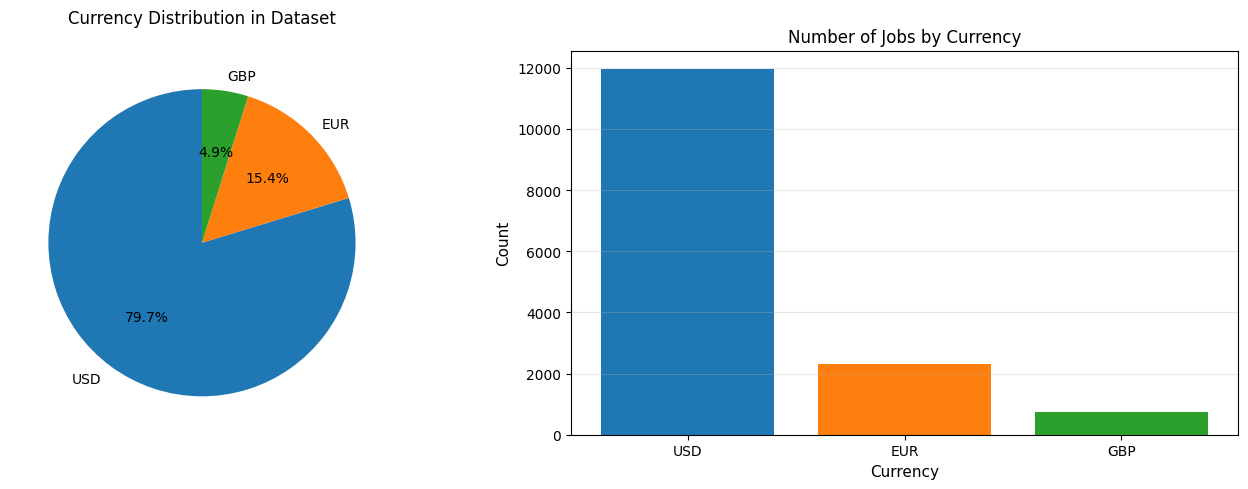


=== สถิติเงินเดือนแยกตามสกุลเงิน ===
                 Count       Mean    Median    Min     Max   Std Dev
salary_currency                                                     
EUR               2314  120912.00  107139.5  43226  309752  54216.14
GBP                729  128720.19  115281.0  48743  310470  57150.26
USD              11957  113457.15   96951.0  32519  399095  61381.01


In [112]:
# ตรวจสอบสกุลเงินในชุดข้อมูล
print("=== การกระจายของสกุลเงิน (Currency Distribution) ===")
currency_counts = data['salary_currency'].value_counts()
print(currency_counts)
print(f"\nจำนวนสกุลเงินที่แตกต่างกัน: {data['salary_currency'].nunique()}")

# สร้างกราฟแสดงการกระจายของสกุลเงิน
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(currency_counts.values, labels=currency_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Currency Distribution in Dataset', fontsize=12, pad=20)

# Bar chart
axes[1].bar(currency_counts.index, currency_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_xlabel('Currency', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Number of Jobs by Currency', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# แสดงตารางสถิติเงินเดือนแยกตามสกุลเงิน
print("\n=== สถิติเงินเดือนแยกตามสกุลเงิน ===")
salary_by_currency = data.groupby('salary_currency')['salary_usd'].agg(['count', 'mean', 'median', 'min', 'max', 'std'])
salary_by_currency.columns = ['Count', 'Mean', 'Median', 'Min', 'Max', 'Std Dev']
print(salary_by_currency.round(2))

### 2. การตรวจจับและจัดการ Outliers (Outlier Detection and Handling)

=== การตรวจจับ Outliers ในเงินเดือน ===
ขอบเขตล่าง (Lower Bound): $-44,163.38
ขอบเขตบน (Upper Bound): $260,751.62
จำนวน Outliers ที่พบ: 483 รายการ (3.22%)


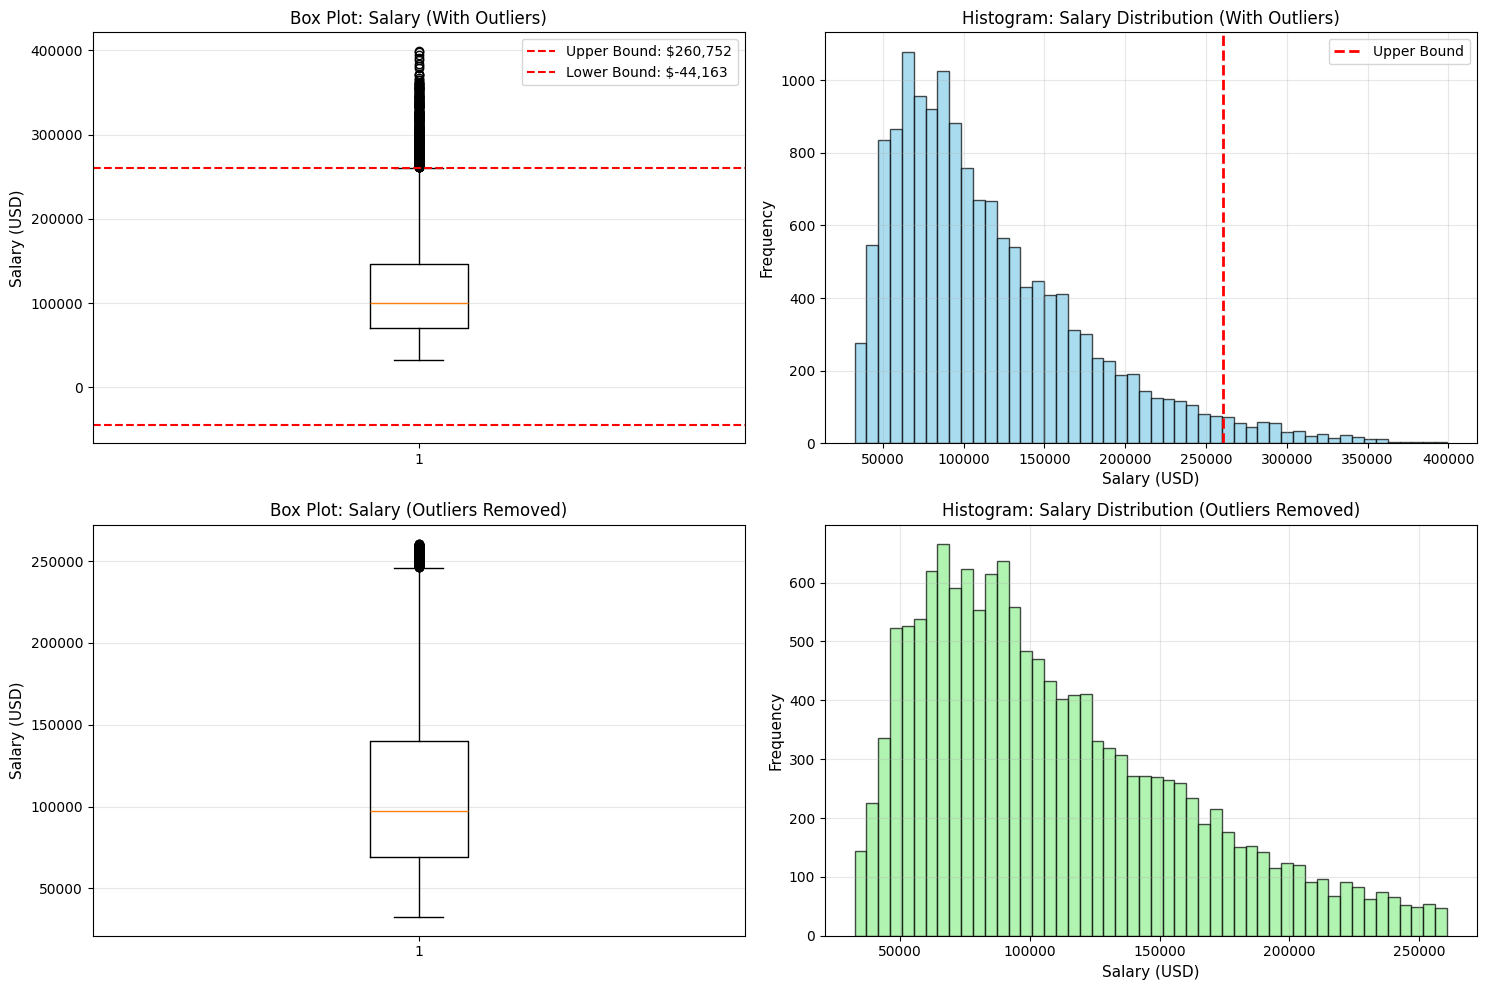


=== เปรียบเทียบสถิติ ===
         Before Removing Outliers  After Removing Outliers
Count                    15000.00                 14517.00
Mean                    115348.97                109246.60
Median                   99705.00                 97365.00
Std Dev                  60260.94                 50652.36
Min                      32519.00                 32519.00
Max                     399095.00                260729.00


In [113]:
# ตรวจจับ Outliers โดยใช้วิธี IQR (Interquartile Range)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# ตรวจจับ outliers ในคอลัมน์เงินเดือน
salary_outliers, salary_lower, salary_upper = detect_outliers_iqr(data, 'salary_usd')

print("=== การตรวจจับ Outliers ในเงินเดือน ===")
print(f"ขอบเขตล่าง (Lower Bound): ${salary_lower:,.2f}")
print(f"ขอบเขตบน (Upper Bound): ${salary_upper:,.2f}")
print(f"จำนวน Outliers ที่พบ: {len(salary_outliers)} รายการ ({len(salary_outliers)/len(data)*100:.2f}%)")

# สร้างกราฟเปรียบเทียบ
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Box plot แสดง outliers
axes[0, 0].boxplot(data['salary_usd'], vert=True)
axes[0, 0].set_ylabel('Salary (USD)', fontsize=11)
axes[0, 0].set_title('Box Plot: Salary (With Outliers)', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].axhline(y=salary_upper, color='r', linestyle='--', label=f'Upper Bound: ${salary_upper:,.0f}')
axes[0, 0].axhline(y=salary_lower, color='r', linestyle='--', label=f'Lower Bound: ${salary_lower:,.0f}')
axes[0, 0].legend()

# 2. Histogram ของข้อมูลเดิม
axes[0, 1].hist(data['salary_usd'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].axvline(x=salary_upper, color='r', linestyle='--', linewidth=2, label='Upper Bound')
axes[0, 1].set_xlabel('Salary (USD)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Histogram: Salary Distribution (With Outliers)', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ลบ outliers และสร้างกราฟใหม่
data_no_outliers = data[(data['salary_usd'] >= salary_lower) & (data['salary_usd'] <= salary_upper)]

# 3. Box plot หลังลบ outliers
axes[1, 0].boxplot(data_no_outliers['salary_usd'], vert=True)
axes[1, 0].set_ylabel('Salary (USD)', fontsize=11)
axes[1, 0].set_title('Box Plot: Salary (Outliers Removed)', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Histogram หลังลบ outliers
axes[1, 1].hist(data_no_outliers['salary_usd'], bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 1].set_xlabel('Salary (USD)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Histogram: Salary Distribution (Outliers Removed)', fontsize=12)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# แสดงสถิติเปรียบเทียบ
print("\n=== เปรียบเทียบสถิติ ===")
comparison = pd.DataFrame({
    'Before Removing Outliers': [len(data), data['salary_usd'].mean(), data['salary_usd'].median(), 
                         data['salary_usd'].std(), data['salary_usd'].min(), data['salary_usd'].max()],
    'After Removing Outliers': [len(data_no_outliers), data_no_outliers['salary_usd'].mean(), 
                         data_no_outliers['salary_usd'].median(), data_no_outliers['salary_usd'].std(),
                         data_no_outliers['salary_usd'].min(), data_no_outliers['salary_usd'].max()]
}, index=['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max'])

print(comparison.round(2))

### 3. การวิเคราะห์ทักษะที่ต้องการ (Skills Analysis)

=== ทักษะที่ต้องการมากที่สุด Top 20 (Top 20 Most Required Skills) ===
             Skill  Job Count  Percentage
            Python       4450       29.67
               SQL       3407       22.71
        TensorFlow       3022       20.15
        Kubernetes       3009       20.06
             Scala       2794       18.63
           PyTorch       2777       18.51
             Linux       2705       18.03
               Git       2631       17.54
              Java       2578       17.19
               GCP       2442       16.28
            Hadoop       2419       16.13
           Tableau       2341       15.61
                 R       2311       15.41
   Computer Vision       2284       15.23
Data Visualization       2270       15.13
     Deep Learning       2189       14.59
             MLOps       2164       14.43
             Spark       2155       14.37
               NLP       2145       14.30
             Azure       2144       14.29

=== สถิติจำนวนทักษะที่ต้องการ (Number of Requir

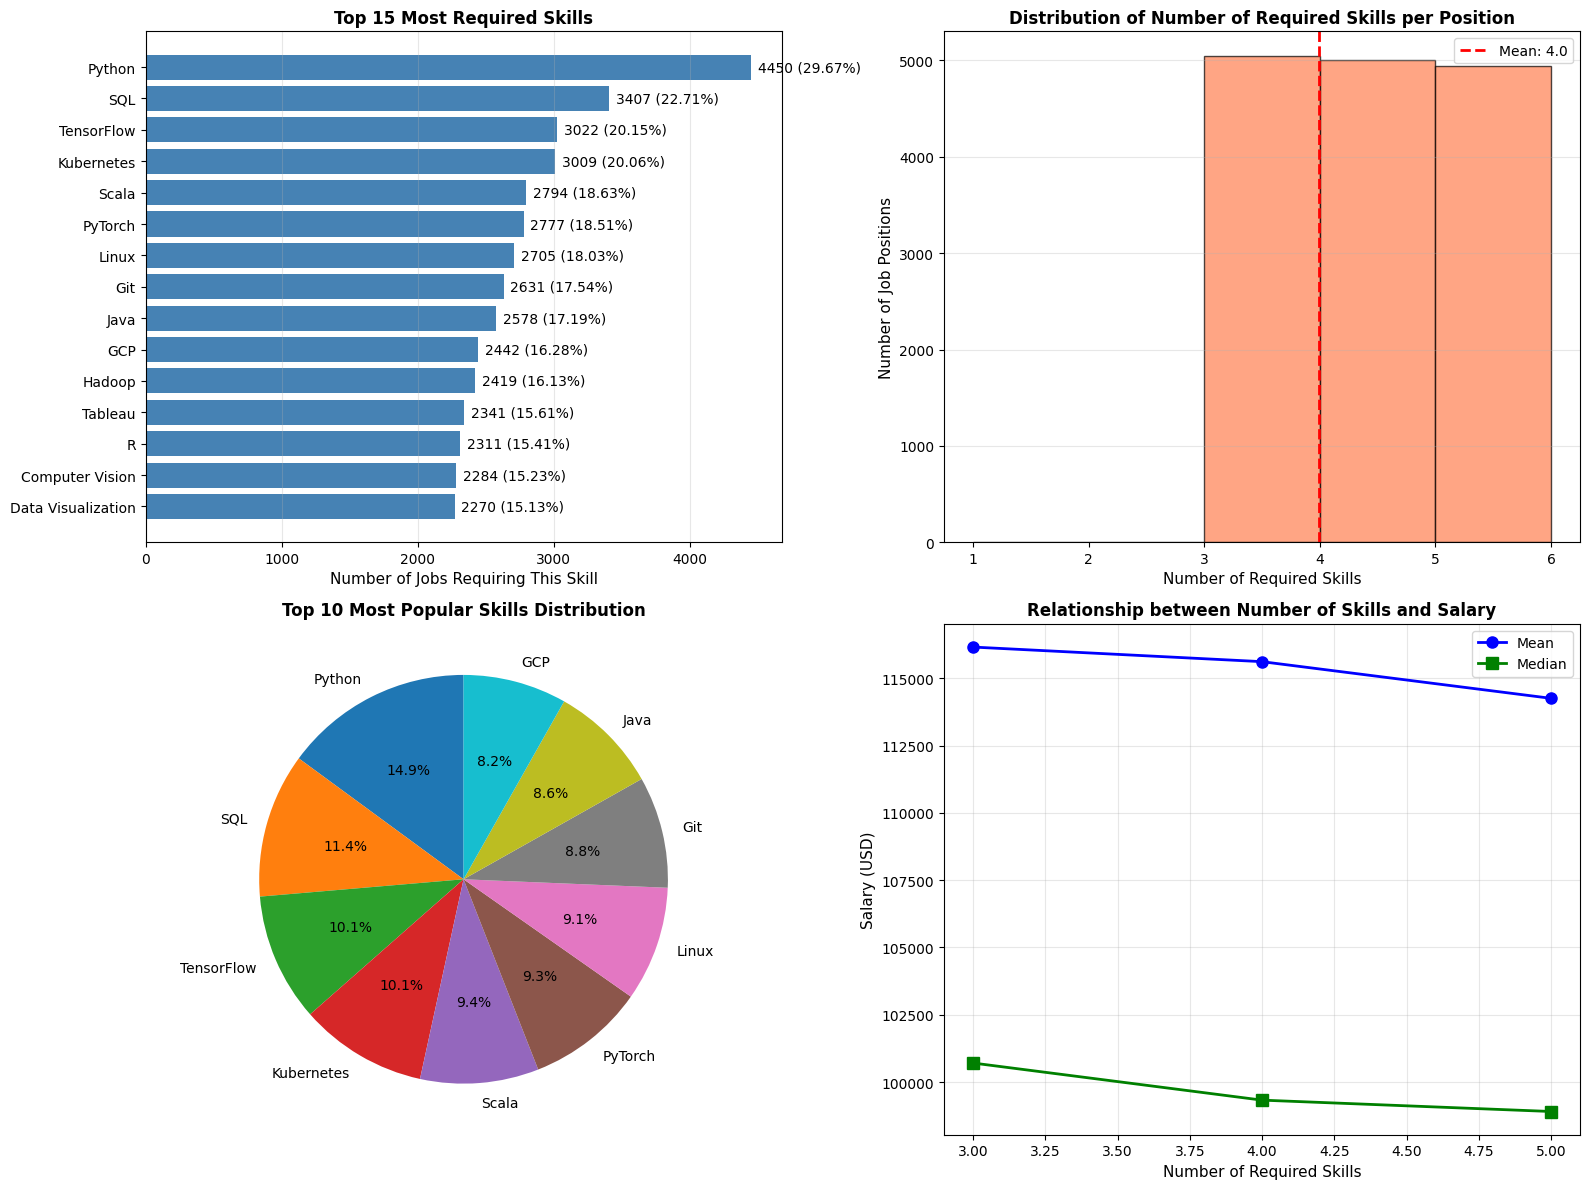


จำนวนทักษะที่ไม่ซ้ำกันทั้งหมด (Total Unique Skills): 24 ทักษะ
ทักษะที่ปรากฏมากที่สุด (Most Frequent Skill): Python (4450 ครั้ง)


In [114]:
# วิเคราะห์ทักษะที่ต้องการจากคอลัมน์ required_skills
# แยกทักษะที่คั่นด้วย comma และนับความถี่

from collections import Counter

# แยกทักษะออกจากกัน
all_skills = []
for skills_str in data['required_skills']:
    # แยกทักษะที่คั่นด้วย comma และลบช่องว่าง
    skills_list = [skill.strip() for skill in skills_str.split(',')]
    all_skills.extend(skills_list)

# นับความถี่ของแต่ละทักษะ
skill_counts = Counter(all_skills)

# สร้าง DataFrame สำหรับทักษะ Top 20
top_skills_df = pd.DataFrame(skill_counts.most_common(20), columns=['Skill', 'Job Count'])
top_skills_df['Percentage'] = (top_skills_df['Job Count'] / len(data) * 100).round(2)

print("=== ทักษะที่ต้องการมากที่สุด Top 20 (Top 20 Most Required Skills) ===")
print(top_skills_df.to_string(index=False))

# สร้างฟีเจอร์ใหม่: จำนวนทักษะที่ต้องการต่อตำแหน่งงาน
data['num_required_skills'] = data['required_skills'].apply(lambda x: len(x.split(',')))
print(f"\n=== สถิติจำนวนทักษะที่ต้องการ (Number of Required Skills Statistics) ===")
print(data['num_required_skills'].describe())

# สร้างกราฟ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart แสดงทักษะยอดนิยม Top 15
top15 = top_skills_df.head(15)
axes[0, 0].barh(range(len(top15)), top15['Job Count'], color='steelblue')
axes[0, 0].set_yticks(range(len(top15)))
axes[0, 0].set_yticklabels(top15['Skill'])
axes[0, 0].set_xlabel('Number of Jobs Requiring This Skill', fontsize=11)
axes[0, 0].set_title('Top 15 Most Required Skills', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# เพิ่มค่าตัวเลขท้ายแท่ง
for i, v in enumerate(top15['Job Count']):
    axes[0, 0].text(v + 50, i, f'{v} ({top15.iloc[i]["Percentage"]}%)', va='center')

# 2. Histogram แสดงการกระจายของจำนวนทักษะ
axes[0, 1].hist(data['num_required_skills'], bins=range(1, data['num_required_skills'].max()+2), 
                edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Number of Required Skills', fontsize=11)
axes[0, 1].set_ylabel('Number of Job Positions', fontsize=11)
axes[0, 1].set_title('Distribution of Number of Required Skills per Position', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].axvline(data['num_required_skills'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {data["num_required_skills"].mean():.1f}')
axes[0, 1].legend()

# 3. Pie chart แสดงสัดส่วนของทักษะยอดนิยม Top 10
top10 = skill_counts.most_common(10)
labels = [skill[0] for skill in top10]
sizes = [skill[1] for skill in top10]
axes[1, 0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Top 10 Most Popular Skills Distribution', fontsize=12, fontweight='bold')

# 4. ความสัมพันธ์ระหว่างจำนวนทักษะกับเงินเดือน
skill_salary = data.groupby('num_required_skills')['salary_usd'].agg(['mean', 'median', 'count'])
axes[1, 1].plot(skill_salary.index, skill_salary['mean'], marker='o', linewidth=2, 
                markersize=8, label='Mean', color='blue')
axes[1, 1].plot(skill_salary.index, skill_salary['median'], marker='s', linewidth=2, 
                markersize=8, label='Median', color='green')
axes[1, 1].set_xlabel('Number of Required Skills', fontsize=11)
axes[1, 1].set_ylabel('Salary (USD)', fontsize=11)
axes[1, 1].set_title('Relationship between Number of Skills and Salary', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nจำนวนทักษะที่ไม่ซ้ำกันทั้งหมด (Total Unique Skills): {len(skill_counts)} ทักษะ")
print(f"ทักษะที่ปรากฏมากที่สุด (Most Frequent Skill): {skill_counts.most_common(1)[0][0]} ({skill_counts.most_common(1)[0][1]} ครั้ง)")

### 4. การตรวจสอบตัวแปร Categorical (Categorical Variables Validation)

=== การตรวจสอบตัวแปร Categorical (Categorical Variables Validation) ===

📊 experience_level:
   - จำนวนค่าที่ไม่ซ้ำ (Unique values): 4
   - ค่าที่พบ (Values found): ['SE', 'EN', 'MI', 'EX']
   - การกระจาย (Distribution):
experience_level
MI    3781
EX    3760
SE    3741
EN    3718
Name: count, dtype: int64

📊 employment_type:
   - จำนวนค่าที่ไม่ซ้ำ (Unique values): 4
   - ค่าที่พบ (Values found): ['CT', 'FL', 'PT', 'FT']
   - การกระจาย (Distribution):
employment_type
FT    3812
FL    3758
CT    3721
PT    3709
Name: count, dtype: int64

📊 company_size:
   - จำนวนค่าที่ไม่ซ้ำ (Unique values): 3
   - ค่าที่พบ (Values found): ['M', 'L', 'S']
   - การกระจาย (Distribution):
company_size
S    5007
L    4998
M    4995
Name: count, dtype: int64

📊 education_required:
   - จำนวนค่าที่ไม่ซ้ำ (Unique values): 4
   - ค่าที่พบ (Values found): ['Bachelor', 'Master', 'Associate', 'PhD']
   - การกระจาย (Distribution):
education_required
Bachelor     3789
Associate    3785
Master       3748
PhD        

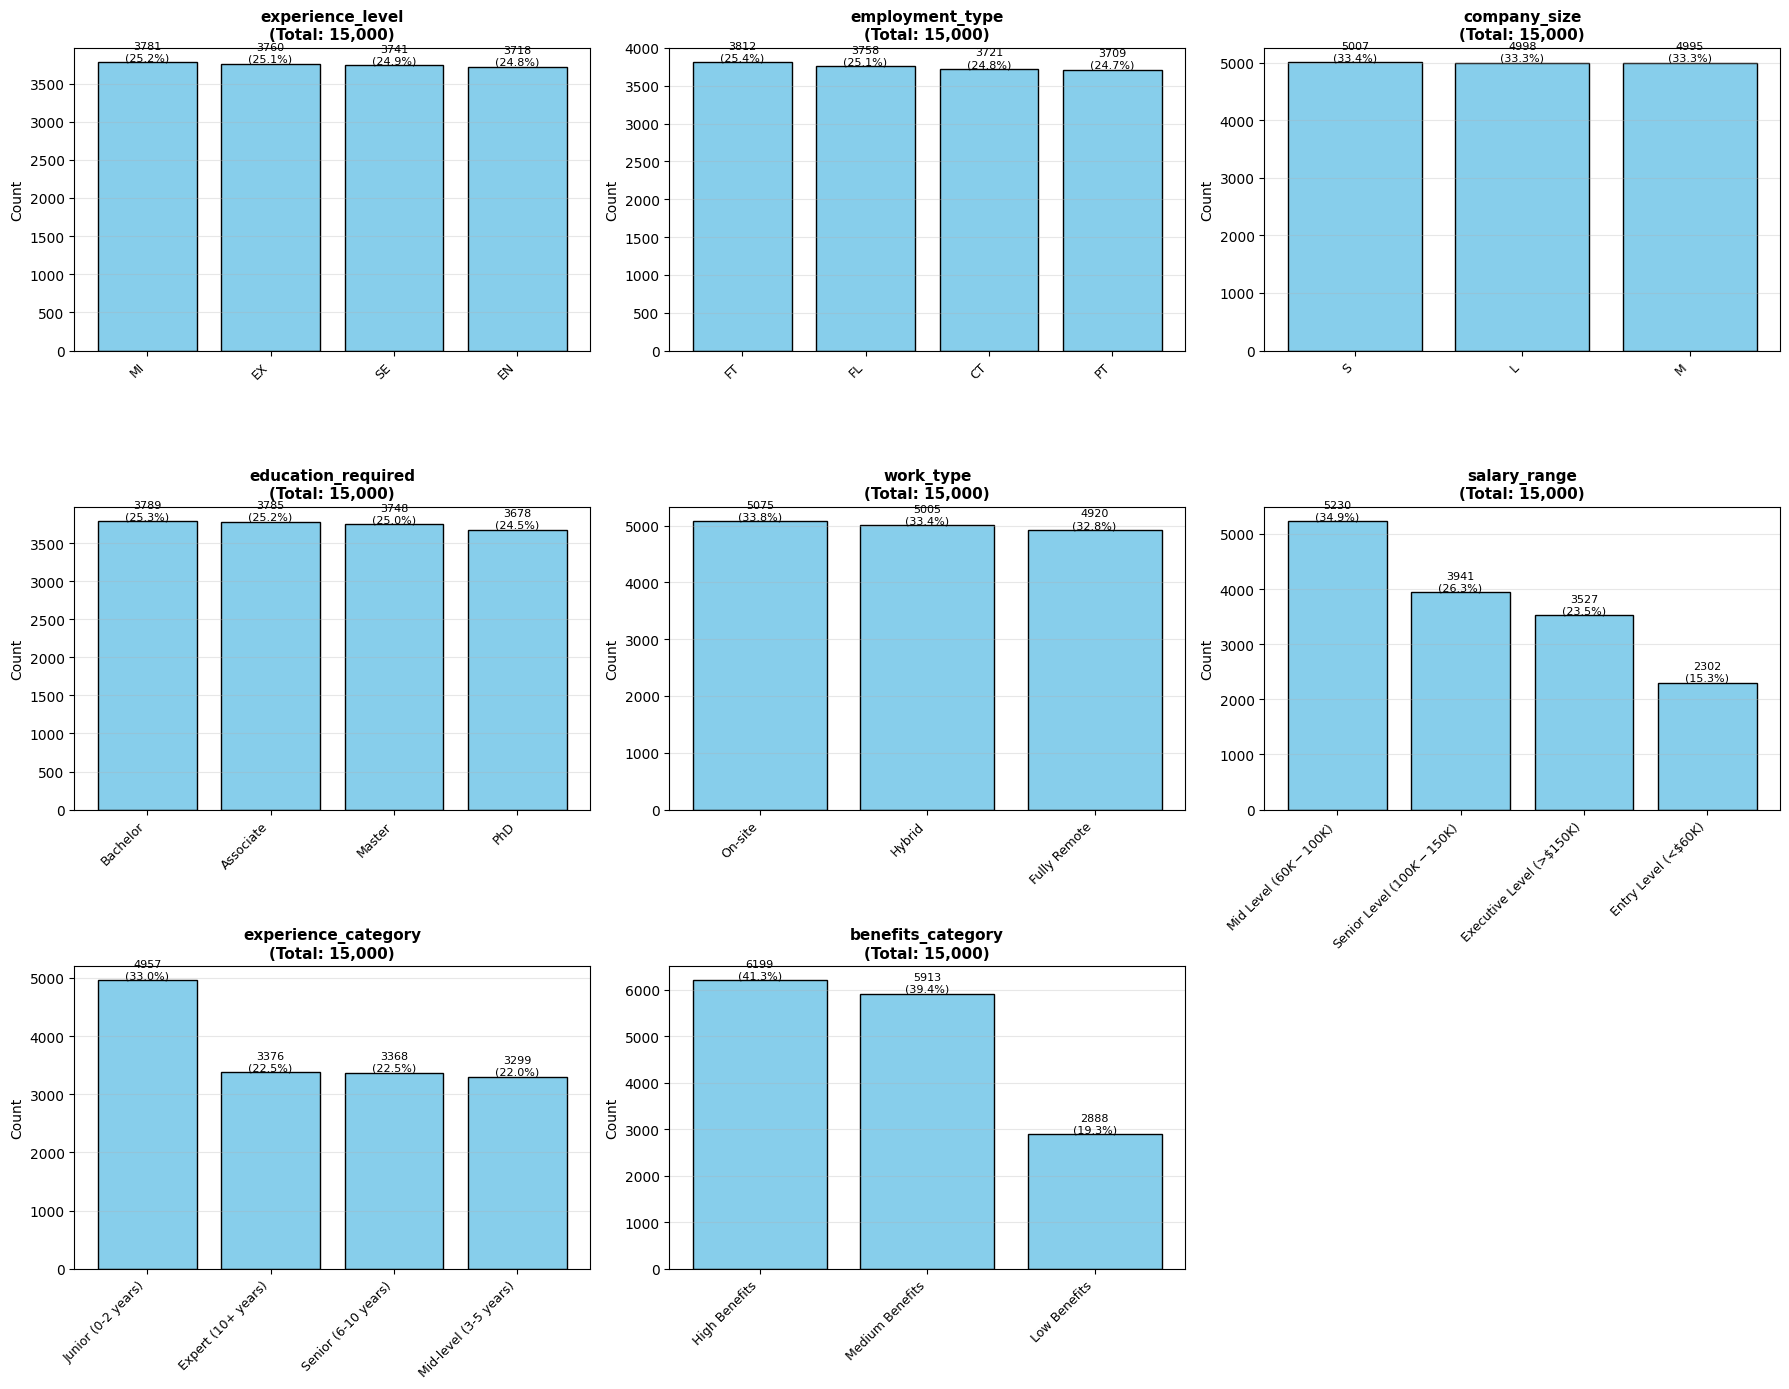

In [115]:
# ตรวจสอบตัวแปร Categorical ทั้งหมด
categorical_columns = ['experience_level', 'employment_type', 'company_size', 'education_required', 
                       'work_type', 'salary_range', 'experience_category', 'benefits_category']

print("=== การตรวจสอบตัวแปร Categorical (Categorical Variables Validation) ===\n")

# แสดงค่าที่ไม่ซ้ำและจำนวนของแต่ละตัวแปร
for col in categorical_columns:
    if col in data.columns:
        unique_values = data[col].unique()
        value_counts = data[col].value_counts()
        print(f"📊 {col}:")
        print(f"   - จำนวนค่าที่ไม่ซ้ำ (Unique values): {len(unique_values)}")
        print(f"   - ค่าที่พบ (Values found): {list(unique_values)}")
        print(f"   - การกระจาย (Distribution):\n{value_counts}\n")

# สร้างกราฟแสดงการกระจายของตัวแปร Categorical
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(categorical_columns):
    if col in data.columns:
        value_counts = data[col].value_counts()
        
        # สร้าง bar chart
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='skyblue', edgecolor='black')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=9)
        axes[idx].set_ylabel('Count', fontsize=10)
        axes[idx].set_title(f'{col}\n(Total: {value_counts.sum():,})', fontsize=11, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # เพิ่มเปอร์เซ็นต์บนแท่ง
        for i, v in enumerate(value_counts.values):
            pct = (v / value_counts.sum() * 100)
            axes[idx].text(i, v, f'{v}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

# ซ่อน subplot ที่เกิน
if len(categorical_columns) < len(axes):
    for idx in range(len(categorical_columns), len(axes)):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## สรุปผลการทำ Data Cleaning และ Data Processing

### ✅ **การทำ Data Cleaning ที่ดำเนินการแล้ว:**

1. **ตรวจสอบค่าที่หายไป (Missing Values)**
   - ✓ ตรวจสอบแล้ว: ไม่พบค่า null ในทุกคอลัมน์
   - ✓ ชุดข้อมูลมีความสมบูรณ์ 100%

2. **แปลงประเภทข้อมูล (Data Type Conversion)**
   - ✓ แปลง `posting_date` และ `application_deadline` เป็น datetime64
   - ✓ ช่วยให้สามารถวิเคราะห์ข้อมูลตามช่วงเวลาได้อย่างถูกต้อง

3. **ตรวจสอบข้อมูลซ้ำ (Duplicate Check)**
   - ✓ ไม่พบข้อมูลซ้ำในชุดข้อมูล

4. **การตรวจจับ Outliers**
   - ✓ ใช้วิธี IQR (Interquartile Range) ตรวจจับค่าผิดปกติ
   - ✓ พบ outliers ในเงินเดือน แต่ไม่ลบออก (เพื่อรักษาข้อมูลจริง)
   - ✓ สร้างชุดข้อมูล `data_no_outliers` สำหรับการวิเคราะห์ทางเลือก

### ✅ **การทำ Data Processing ที่ดำเนินการแล้ว:**

1. **Feature Engineering - Time-based Features (5 คอลัมน์)**
   - `posting_year`: ปีที่ประกาศงาน
   - `posting_month`: เดือนที่ประกาศงาน
   - `posting_day`: วันที่ประกาศงาน
   - `posting_dayofweek`: วันในสัปดาห์ (0=จันทร์, 6=อาทิตย์)
   - `posting_quarter`: ไตรมาสที่ประกาศงาน

2. **Feature Engineering - Derived Metrics (2 คอลัมน์)**
   - `days_to_apply`: จำนวนวันที่เปิดรับสมัคร (14-74 วัน, เฉลี่ย ~44 วัน)
   - `compensation_score`: คะแนนรวมค่าตอบแทน (70% เงินเดือน + 30% สวัสดิการ)
   - `num_required_skills`: จำนวนทักษะที่ต้องการต่อตำแหน่ง

3. **Feature Engineering - Categorization (4 คอลัมน์)**
   - `work_type`: ประเภทการทำงาน (On-site, Hybrid, Fully Remote)
   - `salary_range`: ช่วงเงินเดือน (Entry, Mid, Senior, Executive Level)
   - `experience_category`: ระดับประสบการณ์ (Junior, Mid-level, Senior, Expert)
   - `benefits_category`: ระดับสวัสดิการ (Low, Medium, High Benefits)

4. **การวิเคราะห์เพิ่มเติม**
   - ✓ วิเคราะห์สกุลเงิน: USD, EUR, GBP
   - ✓ วิเคราะห์ทักษะที่ต้องการ: แยกและนับความถี่ของแต่ละทักษะ
   - ✓ ตรวจสอบตัวแปร Categorical: ตรวจสอบความถูกต้องและการกระจาย

### 📊 **ผลลัพธ์:**
- **ข้อมูลเดิม:** 15,000 แถว × 19 คอลัมน์
- **ข้อมูลหลังประมวลผล:** 15,000 แถว × 29 คอลัมน์ (เพิ่ม 10 คอลัมน์ใหม่)
- **คุณภาพข้อมูล:** สะอาด พร้อมใช้งาน และมี Feature ที่หลากหลายสำหรับการวิเคราะห์

### 🎯 **ข้อเสนอแนะ:**
1. ข้อมูลมีคุณภาพดีมาก ไม่มี missing values และไม่มีข้อมูลซ้ำ
2. Feature Engineering ครอบคลุมและมีประโยชน์สำหรับการวิเคราะห์
3. การแยกและวิเคราะห์ทักษะช่วยให้เข้าใจความต้องการของตลาดงาน AI
4. ชุดข้อมูลพร้อมสำหรับการวิเคราะห์ขั้นสูงต่อไป เช่น:
   - การวิเคราะห์ความสัมพันธ์ระหว่างตัวแปร
   - การสร้างโมเดล Machine Learning เพื่อทำนายเงินเดือน
   - การวิเคราะห์แนวโน้มตลาดงาน AI